# Centroid Analysis: Calibration Dataset Sensitivity

Compare KV cache centroids from two calibration datasets:
- **Dataset A**: `mmlu_pro-10000-tokens`
- **Dataset B**: `hendrycks_math-10000-tokens`

Model: Qwen3-4B-Thinking-2507, n_clusters=256, 36 layers

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from pathlib import Path
import os

# ── Config ────────────────────────────────────────────────────────────────────
KV_BASE    = Path('/data/jisenli2/kv-cache/Qwen3-4B-Thinking-2507')
DATASET_A  = 'mmlu_pro-10000-tokens'
DATASET_B  = 'hendrycks_math-10000-tokens'
N_CLUSTERS = 256
NUM_LAYERS = 36
OUT_DIR    = Path('analysis_outputs')
OUT_DIR.mkdir(exist_ok=True)

# Layers to use for PCA visualizations
VIZ_LAYERS = [0, 4, 8, 16, 24, 32, 35]

def load_centroids(dataset, layer, kv, n_clusters=N_CLUSTERS):
    path = KV_BASE / dataset / f'c_{n_clusters}' / f'{kv}_layer_{layer}_clusters_{n_clusters}_centers.pt'
    return torch.load(path, map_location='cpu').float().numpy()  # [C, D]

def load_token_embeddings(dataset, layer):
    path = KV_BASE / dataset / f'kv_calibration_layer_{layer}.pt'
    data = torch.load(path, map_location='cpu')
    # data['k']: [T, H, D]  →  flatten to [T, H*D]
    k = data['k'].float().numpy().reshape(data['k'].shape[0], -1)
    v = data['v'].float().numpy().reshape(data['v'].shape[0], -1)
    return k, v

print('Paths OK:', (KV_BASE / DATASET_A / f'c_{N_CLUSTERS}').exists(),
                   (KV_BASE / DATASET_B / f'c_{N_CLUSTERS}').exists())

Paths OK: True True


## Part 1 — Per-layer Symmetric Nearest-Neighbor Distance

In [2]:
def sym_nn_distance(A, B):
    """
    Symmetric nearest-neighbor distance between two centroid sets.
    A, B: [C, D] numpy arrays
    d(A,B) = 0.5 * (mean_i min_j ||a_i - b_j|| + mean_j min_i ||a_i - b_j||)
    """
    # Pairwise L2: [C_A, C_B]
    diff = A[:, None, :] - B[None, :, :]   # [C_A, C_B, D]
    D = np.sqrt((diff ** 2).sum(axis=-1))  # [C_A, C_B]
    a2b = D.min(axis=1).mean()             # each A → nearest B
    b2a = D.min(axis=0).mean()             # each B → nearest A
    return 0.5 * (a2b + b2a)

dist_k = []
dist_v = []

for layer in range(NUM_LAYERS):
    ck_a = load_centroids(DATASET_A, layer, 'k')
    ck_b = load_centroids(DATASET_B, layer, 'k')
    cv_a = load_centroids(DATASET_A, layer, 'v')
    cv_b = load_centroids(DATASET_B, layer, 'v')
    dist_k.append(sym_nn_distance(ck_a, ck_b))
    dist_v.append(sym_nn_distance(cv_a, cv_b))
    if layer % 6 == 0:
        print(f'Layer {layer:2d}  dist_k={dist_k[-1]:.4f}  dist_v={dist_v[-1]:.4f}')

dist_k = np.array(dist_k)
dist_v = np.array(dist_v)
print(f'\nK  mean={dist_k.mean():.4f}  std={dist_k.std():.4f}  min={dist_k.min():.4f}  max={dist_k.max():.4f}')
print(f'V  mean={dist_v.mean():.4f}  std={dist_v.std():.4f}  min={dist_v.min():.4f}  max={dist_v.max():.4f}')

Layer  0  dist_k=37.6856  dist_v=0.4768
Layer  6  dist_k=29.4882  dist_v=4.5799
Layer 12  dist_k=38.4876  dist_v=8.4183
Layer 18  dist_k=38.1617  dist_v=11.7891
Layer 24  dist_k=41.1442  dist_v=24.3212
Layer 30  dist_k=34.8255  dist_v=50.7506

K  mean=37.0539  std=5.3572  min=27.3237  max=60.4346
V  mean=23.8166  std=28.1892  min=0.4768  max=114.3872


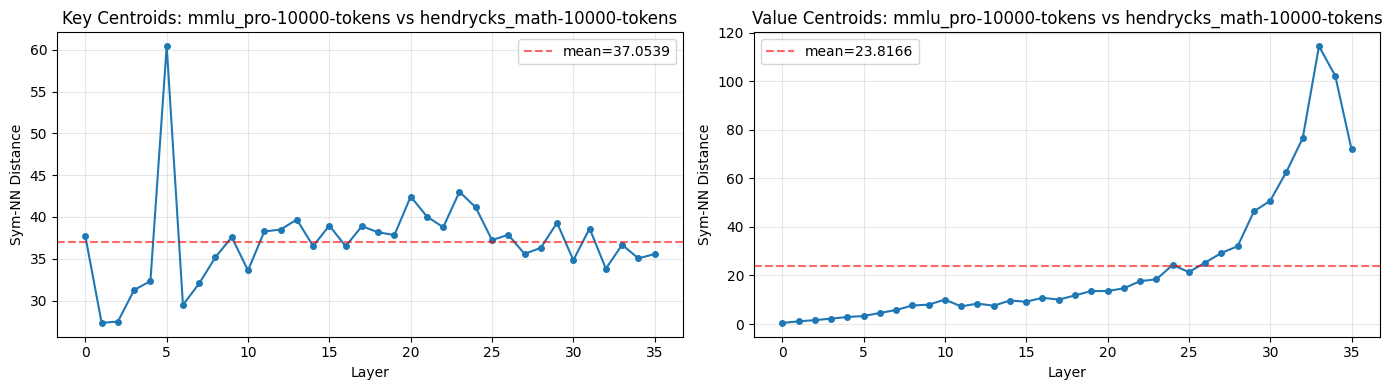

Saved → analysis_outputs/layer_distance.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
layers = np.arange(NUM_LAYERS)

for ax, dist, kv_label in zip(axes, [dist_k, dist_v], ['Key', 'Value']):
    ax.plot(layers, dist, marker='o', markersize=4, linewidth=1.5)
    ax.axhline(dist.mean(), linestyle='--', color='red', alpha=0.6, label=f'mean={dist.mean():.4f}')
    ax.set_xlabel('Layer')
    ax.set_ylabel('Sym-NN Distance')
    ax.set_title(f'{kv_label} Centroids: {DATASET_A} vs {DATASET_B}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'layer_distance.png', dpi=150)
plt.show()
print(f'Saved → {OUT_DIR}/layer_distance.png')

## Part 2 — PCA 2D Overlay (Centroids from Both Datasets)

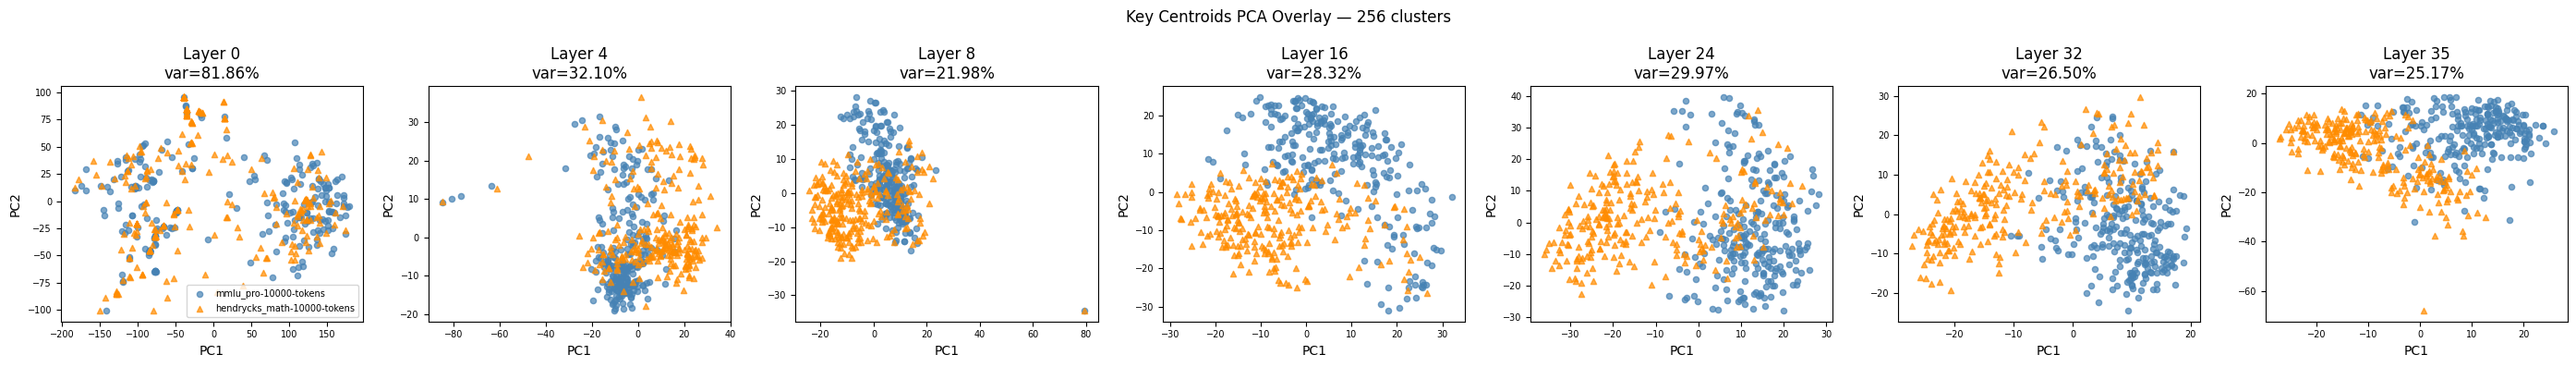

Saved → analysis_outputs/pca_overlay_k.png


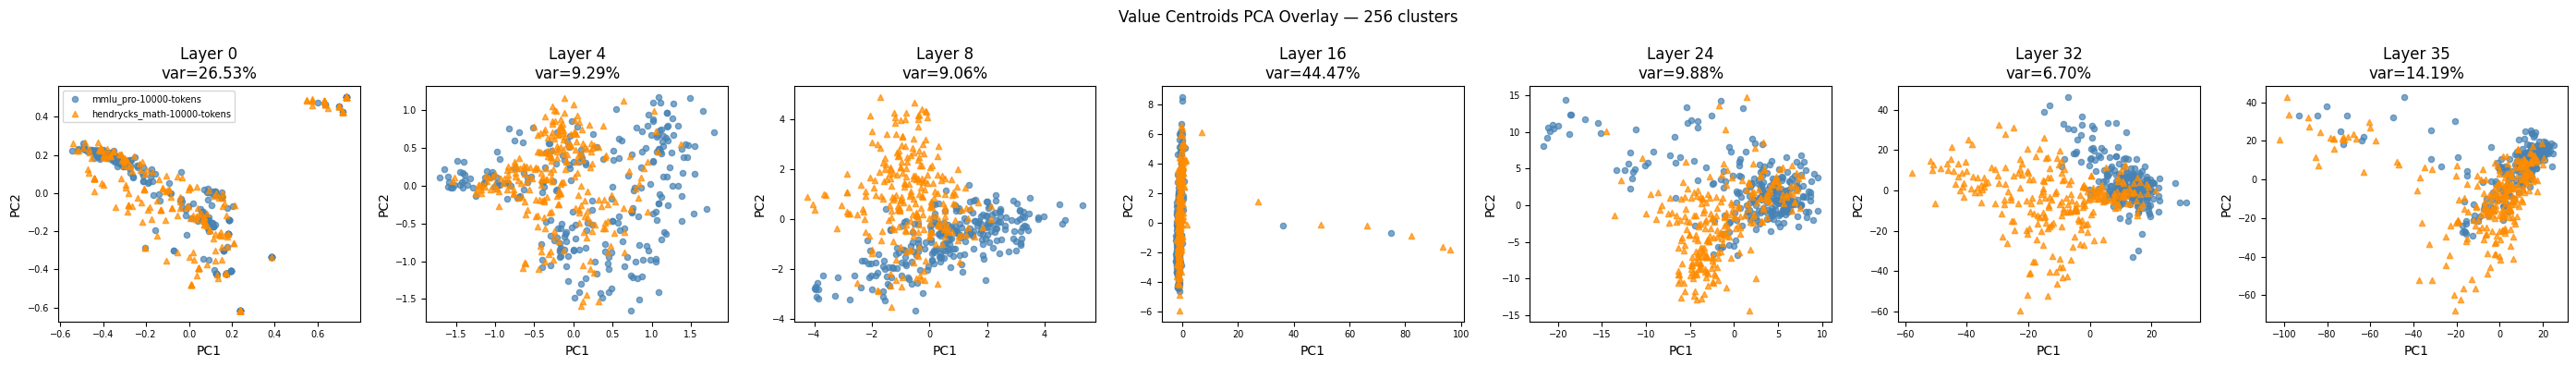

Saved → analysis_outputs/pca_overlay_v.png


In [4]:
for kv in ['k', 'v']:
    n_viz = len(VIZ_LAYERS)
    fig, axes = plt.subplots(1, n_viz, figsize=(4 * n_viz, 4))
    kv_label = 'Key' if kv == 'k' else 'Value'

    for ax, layer in zip(axes, VIZ_LAYERS):
        ca = load_centroids(DATASET_A, layer, kv)  # [C, D]
        cb = load_centroids(DATASET_B, layer, kv)

        # Fit PCA on combined centroids
        combined = np.concatenate([ca, cb], axis=0)  # [2C, D]
        pca = PCA(n_components=2)
        proj = pca.fit_transform(combined)           # [2C, 2]
        pa, pb = proj[:N_CLUSTERS], proj[N_CLUSTERS:]

        ax.scatter(pa[:, 0], pa[:, 1], s=20, alpha=0.7, label=DATASET_A, color='steelblue')
        ax.scatter(pb[:, 0], pb[:, 1], s=20, alpha=0.7, label=DATASET_B, color='darkorange', marker='^')
        ax.set_title(f'Layer {layer}\nvar={pca.explained_variance_ratio_[:2].sum():.2%}')
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
        ax.tick_params(labelsize=7)
        if layer == VIZ_LAYERS[0]:
            ax.legend(fontsize=7)

    fig.suptitle(f'{kv_label} Centroids PCA Overlay — {N_CLUSTERS} clusters', fontsize=12)
    plt.tight_layout()
    out_path = OUT_DIR / f'pca_overlay_{kv}.png'
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f'Saved → {out_path}')

## Part 3 — Token Point Cloud + Centroids Joint PCA

Pick a few layers; subsample tokens to keep it readable.

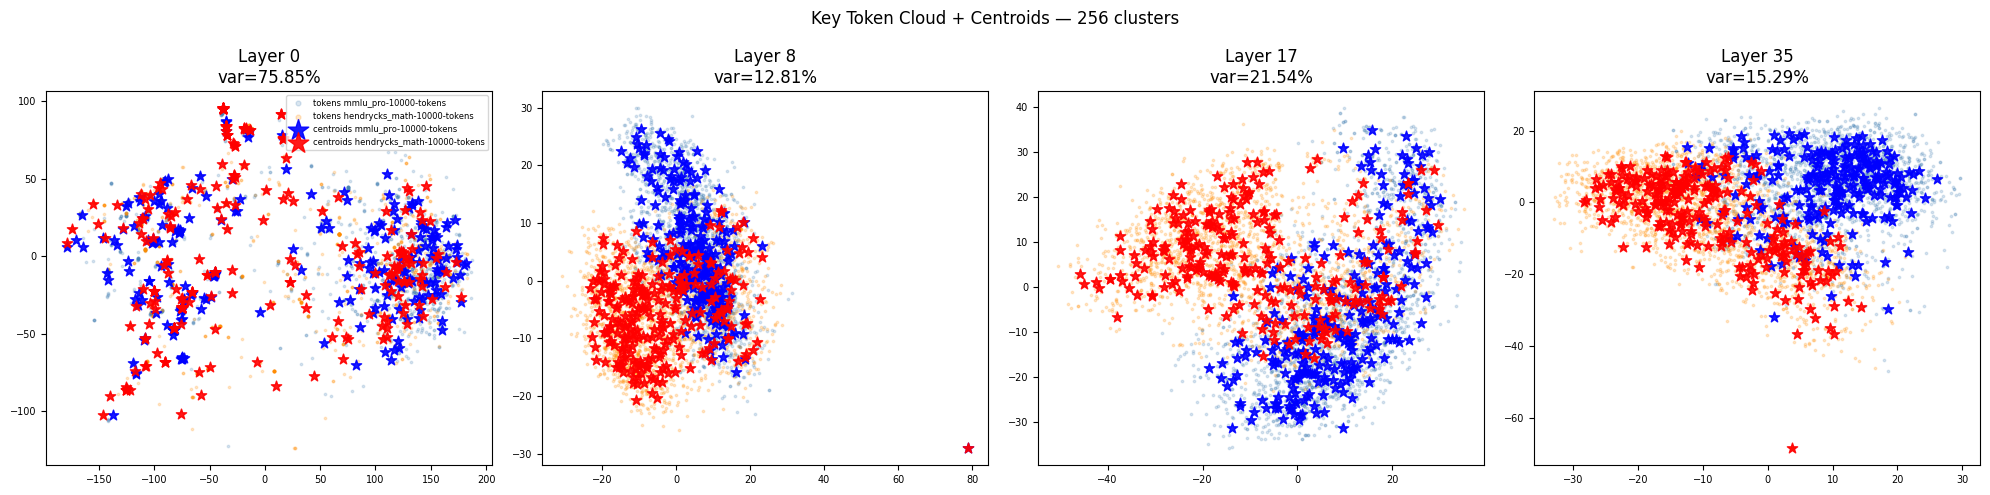

Saved → analysis_outputs/token_centroid_pca_k.png


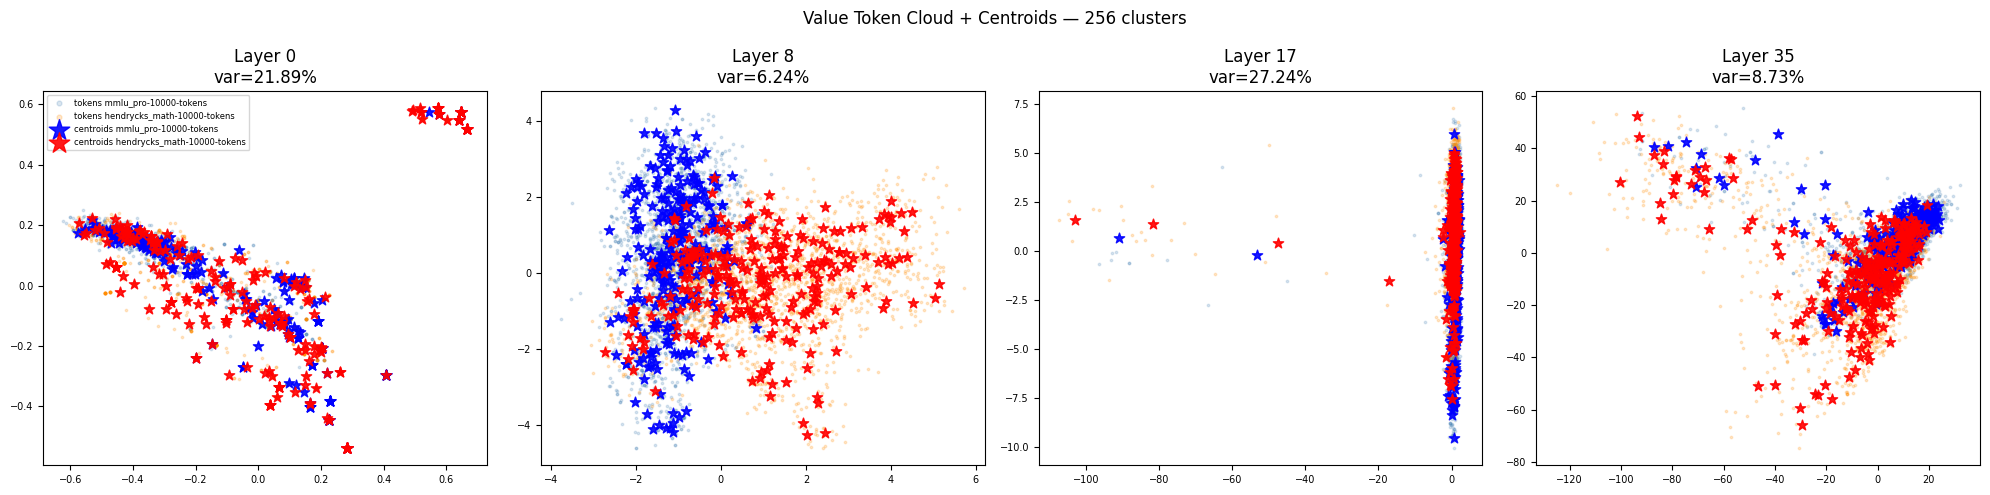

Saved → analysis_outputs/token_centroid_pca_v.png


In [5]:
TOKEN_SUBSAMPLE = 2000   # number of tokens to plot per dataset
TOKEN_VIZ_LAYERS = [0, 8, 17, 35]

for kv in ['k', 'v']:
    kv_label = 'Key' if kv == 'k' else 'Value'
    n_viz = len(TOKEN_VIZ_LAYERS)
    fig, axes = plt.subplots(1, n_viz, figsize=(5 * n_viz, 5))

    for ax, layer in zip(axes, TOKEN_VIZ_LAYERS):
        # Load tokens
        ta, _ = load_token_embeddings(DATASET_A, layer)  # use k or v
        tb, _ = load_token_embeddings(DATASET_B, layer)
        if kv == 'v':
            _, ta = load_token_embeddings(DATASET_A, layer)
            _, tb = load_token_embeddings(DATASET_B, layer)

        # Subsample tokens
        rng = np.random.default_rng(42)
        idx_a = rng.choice(len(ta), min(TOKEN_SUBSAMPLE, len(ta)), replace=False)
        idx_b = rng.choice(len(tb), min(TOKEN_SUBSAMPLE, len(tb)), replace=False)
        ta_s, tb_s = ta[idx_a], tb[idx_b]

        # Load centroids
        ca = load_centroids(DATASET_A, layer, kv)
        cb = load_centroids(DATASET_B, layer, kv)

        # Fit PCA on tokens only
        all_tokens = np.concatenate([ta_s, tb_s], axis=0)
        pca = PCA(n_components=2)
        pca.fit(all_tokens)

        # Project tokens and centroids
        pa_t = pca.transform(ta_s)
        pb_t = pca.transform(tb_s)
        pa_c = pca.transform(ca)
        pb_c = pca.transform(cb)

        ax.scatter(pa_t[:, 0], pa_t[:, 1], s=3,  alpha=0.2, color='steelblue',  label=f'tokens {DATASET_A}')
        ax.scatter(pb_t[:, 0], pb_t[:, 1], s=3,  alpha=0.2, color='darkorange', label=f'tokens {DATASET_B}')
        ax.scatter(pa_c[:, 0], pa_c[:, 1], s=60, alpha=0.9, color='blue',   marker='*', label=f'centroids {DATASET_A}')
        ax.scatter(pb_c[:, 0], pb_c[:, 1], s=60, alpha=0.9, color='red',    marker='*', label=f'centroids {DATASET_B}')
        ax.set_title(f'Layer {layer}\nvar={pca.explained_variance_ratio_[:2].sum():.2%}')
        ax.tick_params(labelsize=7)
        if layer == TOKEN_VIZ_LAYERS[0]:
            ax.legend(fontsize=6, markerscale=2)

    fig.suptitle(f'{kv_label} Token Cloud + Centroids — {N_CLUSTERS} clusters', fontsize=12)
    plt.tight_layout()
    out_path = OUT_DIR / f'token_centroid_pca_{kv}.png'
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f'Saved → {out_path}')

## Part 4 — Summary Statistics

Compare sym-NN distance to intra-cluster spread (average distance from tokens to their nearest centroid) to judge whether inter-dataset differences are large or small relative to the KV space scale.

In [9]:
intra_k, intra_v = [], []

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

def intra_cluster_dist_torch(tokens_np, cents_np, device=DEVICE):
    """Mean distance from each token to its nearest centroid, using torch.cdist."""
    t = torch.from_numpy(tokens_np).to(device)   # [T, D]
    c = torch.from_numpy(cents_np).to(device)    # [C, D]
    dists = torch.cdist(t, c)                    # [T, C]
    return dists.min(dim=1).values.mean().item()

for layer in range(NUM_LAYERS):
    data = torch.load(KV_BASE / DATASET_A / f'kv_calibration_layer_{layer}.pt', map_location='cpu')
    tk = data['k'].float().reshape(data['k'].shape[0], -1).numpy()  # [T, D]
    tv = data['v'].float().reshape(data['v'].shape[0], -1).numpy()

    ck = load_centroids(DATASET_A, layer, 'k')
    cv = load_centroids(DATASET_A, layer, 'v')

    intra_k.append(intra_cluster_dist_torch(tk, ck))
    intra_v.append(intra_cluster_dist_torch(tv, cv))

    if layer % 6 == 0:
        print(f'Layer {layer:2d}  intra_k={intra_k[-1]:.4f}  intra_v={intra_v[-1]:.4f}')

intra_k = np.array(intra_k)
intra_v = np.array(intra_v)

print(f'\n=== Summary ===')
print(f'{"":25s}  {"K":>10}  {"V":>10}')
print(f'{"Sym-NN dist mean":25s}  {dist_k.mean():10.4f}  {dist_v.mean():10.4f}')
print(f'{"Intra-cluster mean":25s}  {intra_k.mean():10.4f}  {intra_v.mean():10.4f}')
print(f'{"Ratio (sym/intra) mean":25s}  {(dist_k/intra_k).mean():10.4f}  {(dist_v/intra_v).mean():10.4f}')
print()
print('Ratio < 1: inter-dataset diff < quantization error → calibration dataset not critical')
print('Ratio > 1: inter-dataset diff dominates → calibration dataset matters')


Using device: cuda:0
Layer  0  intra_k=36.4440  intra_v=0.3811
Layer  6  intra_k=30.9728  intra_v=3.9496
Layer 12  intra_k=34.2325  intra_v=7.5410
Layer 18  intra_k=31.8323  intra_v=11.5520
Layer 24  intra_k=32.7617  intra_v=24.5571
Layer 30  intra_k=31.9674  intra_v=48.5932

=== Summary ===
                                    K           V
Sym-NN dist mean              37.0539     23.8166
Intra-cluster mean            33.7149     22.2828
Ratio (sym/intra) mean         1.1002      1.0630

Ratio < 1: inter-dataset diff < quantization error → calibration dataset not critical
Ratio > 1: inter-dataset diff dominates → calibration dataset matters


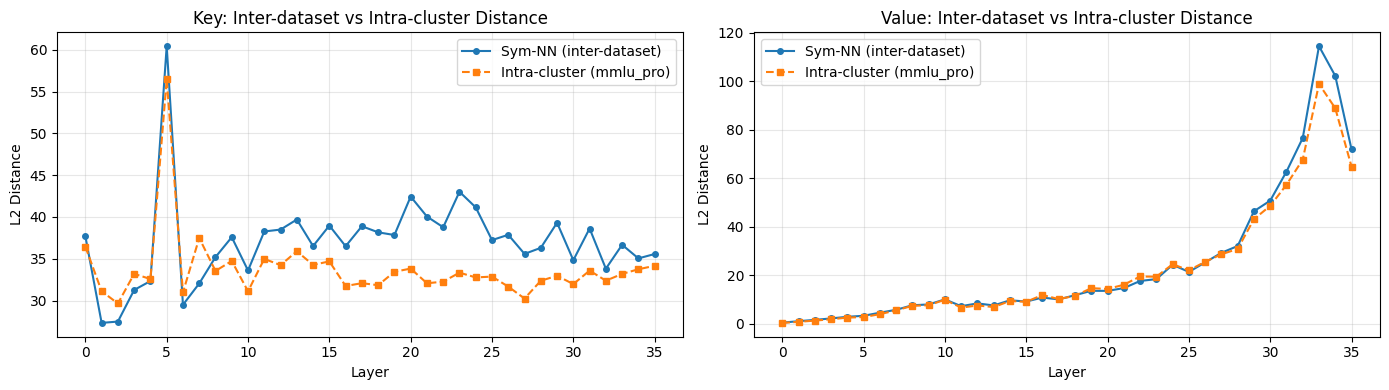

Saved → analysis_outputs/distance_comparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
layers = np.arange(NUM_LAYERS)

for ax, sym, intra, kv_label in zip(axes,
        [dist_k, dist_v], [intra_k, intra_v], ['Key', 'Value']):
    ax.plot(layers, sym,   marker='o', markersize=4, linewidth=1.5, label='Sym-NN (inter-dataset)')
    ax.plot(layers, intra, marker='s', markersize=4, linewidth=1.5, label='Intra-cluster (mmlu_pro)', linestyle='--')
    ax.set_xlabel('Layer')
    ax.set_ylabel('L2 Distance')
    ax.set_title(f'{kv_label}: Inter-dataset vs Intra-cluster Distance')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'distance_comparison.png', dpi=150)
plt.show()
print(f'Saved → {OUT_DIR}/distance_comparison.png')